In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression ,Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score
from sklearn.impute import KNNImputer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

## Reading Data

---

In [2]:
data = pd.read_csv('CreditPrediction.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10167 entries, 0 to 10166
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10167 non-null  int64  
 1   Customer_Age              10167 non-null  float64
 2   Gender                    9968 non-null   object 
 3   Dependent_count           10167 non-null  int64  
 4   Education_Level           10167 non-null  object 
 5   Marital_Status            8217 non-null   object 
 6   Income_Category           10167 non-null  object 
 7   Card_Category             8243 non-null   object 
 8   Months_on_book            9944 non-null   float64
 9   Total_Relationship_Count  10147 non-null  float64
 10  Months_Inactive_12_mon    10167 non-null  int64  
 11  Contacts_Count_12_mon     10167 non-null  int64  
 12  Credit_Limit              10167 non-null  float64
 13  Total_Revolving_Bal       10167 non-null  int64  
 14  Total_

In [4]:
# Rmoving extra columns
data = data.drop(columns=['CLIENTNUM'])
data = data.drop(columns=['Unnamed: 19'])

In [5]:
# Removing duplicate rows
data = data.drop_duplicates().reset_index(drop=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10132 entries, 0 to 10131
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_Age              10132 non-null  float64
 1   Gender                    9933 non-null   object 
 2   Dependent_count           10132 non-null  int64  
 3   Education_Level           10132 non-null  object 
 4   Marital_Status            8193 non-null   object 
 5   Income_Category           10132 non-null  object 
 6   Card_Category             8217 non-null   object 
 7   Months_on_book            9911 non-null   float64
 8   Total_Relationship_Count  10112 non-null  float64
 9   Months_Inactive_12_mon    10132 non-null  int64  
 10  Contacts_Count_12_mon     10132 non-null  int64  
 11  Credit_Limit              10132 non-null  float64
 12  Total_Revolving_Bal       10132 non-null  int64  
 13  Total_Amt_Chng_Q4_Q1      10132 non-null  float64
 14  Total_

## Outlier treatment

---

In [7]:
df_numerical_cols=['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 
    'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
    'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

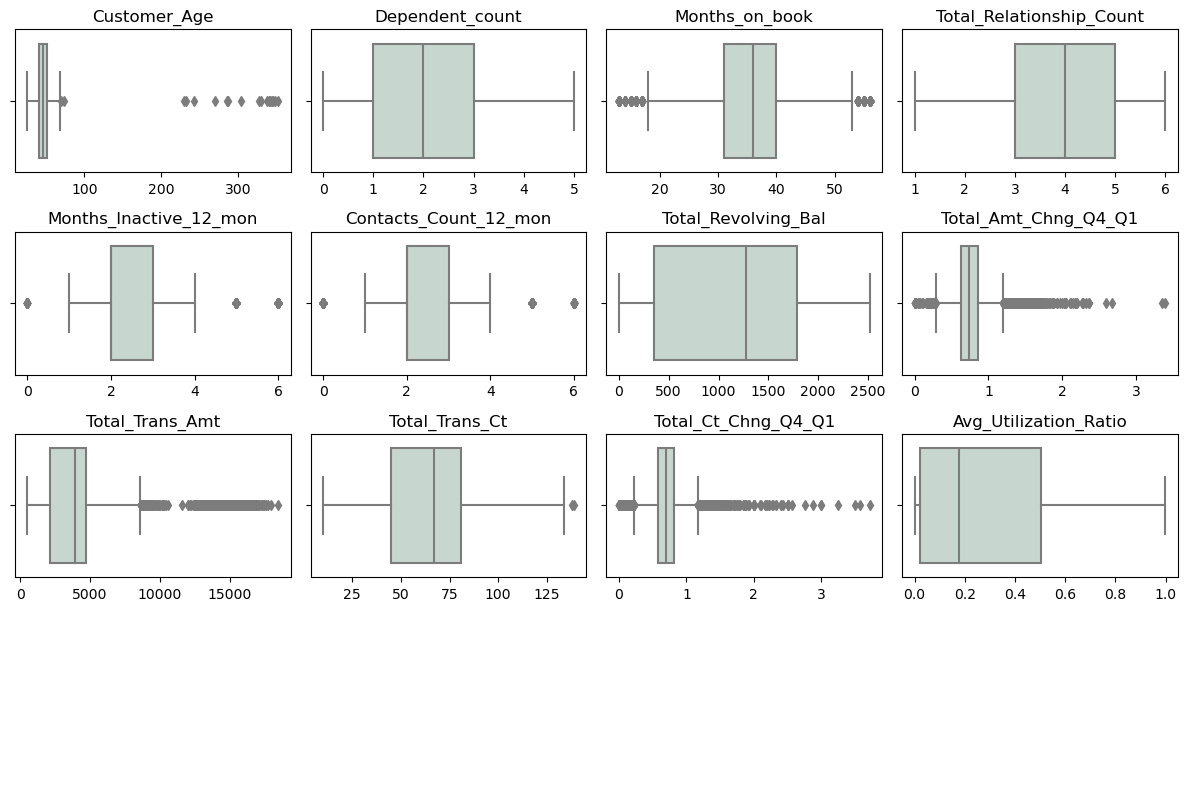

In [8]:
num_features = len(df_numerical_cols)

fig, axes = plt.subplots(4, 4, figsize=(12, 8))
feature_num = 0

for i in range(4):
    for j in range(4):
        if feature_num < num_features:
            col = df_numerical_cols[feature_num]
            sns.boxplot(x=data[col], color='#c4d9cf', ax=axes[i, j])
            axes[i, j].set_title(col)
            axes[i, j].set_xlabel('')
        else:
            axes[i, j].axis('off')
        feature_num += 1

plt.tight_layout()
plt.show()

In [9]:
cols = ['Customer_Age','Total_Amt_Chng_Q4_Q1','Total_Trans_Amt','Total_Ct_Chng_Q4_Q1']

In [10]:
for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[col] = data[col].clip(lower, upper)

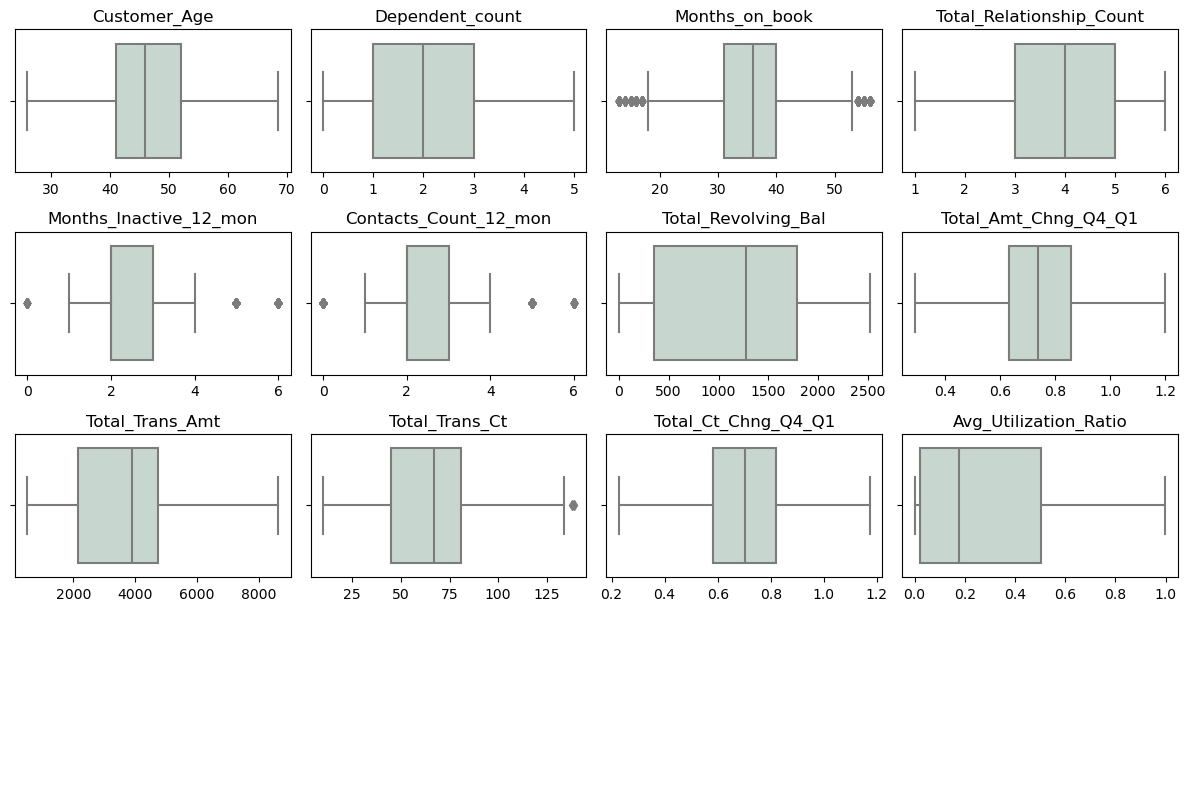

In [11]:
num_features = len(df_numerical_cols)

fig, axes = plt.subplots(4, 4, figsize=(12, 8))
feature_num = 0

for i in range(4):
    for j in range(4):
        if feature_num < num_features:
            col = df_numerical_cols[feature_num]
            sns.boxplot(x=data[col], color='#c4d9cf', ax=axes[i, j])
            axes[i, j].set_title(col)
            axes[i, j].set_xlabel('')
        else:
            axes[i, j].axis('off')
        feature_num += 1

plt.tight_layout()
plt.show()

## Handling Non-Numeric Data

---

In [12]:
data['Gender'].unique()

array(['M', 'F', nan], dtype=object)

In [13]:
mode_Gender = data['Gender'].mode()[0]

In [14]:
data['Gender'] = data['Gender'].fillna(mode_Gender)

In [15]:
data['Gender_numeric'] = data['Gender'].map({'M':1,'F':0})

In [16]:
data['Education_Level'].unique()

array(['High School', 'Graduate', 'Uneducated', 'Unknown', 'College',
       'Post-Graduate', 'Doctorate'], dtype=object)

In [17]:
Education_order = {'Uneducated':0,'High School':1,'College':2,'Graduate':3,'Post-Graduate':4,'Doctorate':5,'Unknown':np.nan}

In [18]:
data['Education_Level_encoded']=data['Education_Level'].map(Education_order)

In [19]:
data['Marital_Status'].unique()

array(['Married', nan, 'Unknown', 'Single', 'Divorced'], dtype=object)

In [20]:
data['Marital_Status_encoded'] = data['Marital_Status'].map({'Married':1,'Single':0,'Divorced':2,'Unknown':np.nan})

In [21]:
data['Income_Category'].unique()

array(['$60K - $80K', 'Less than $40K', '$80K - $120K', '$40K - $60K',
       '$120K +', 'Unknown'], dtype=object)

In [22]:
income_order = { 'Less than $40K': 1, '$40K - $60K': 2, '$60K - $80K': 3,'$80K - $120K': 4,  '$120K +': 5,'Unknown':np.nan}

In [23]:
data['Income_Category_encoded'] = data['Income_Category'].map(income_order)

In [24]:
card_order = {  'Blue': 1,  'Silver': 2,   'Gold': 3,   'Platinum': 4}

In [25]:
data['Card_Category_encoded'] = data['Card_Category'].map(card_order)

## Imputation null values

---

Before imputation i split train test data to escape data leakage

In [26]:
X = data.drop(columns=['Credit_Limit','Education_Level','Gender','Marital_Status','Income_Category','Card_Category'])

In [27]:
y = data['Credit_Limit']

In [28]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
target_cols = [ 'Education_Level_encoded', 'Income_Category_encoded', 'Card_Category_encoded', 'Marital_Status_encoded']

In [30]:
feature_cols = [ 'Total_Trans_Amt', 'Customer_Age', 'Dependent_count', 'Avg_Utilization_Ratio', 'Total_Ct_Chng_Q4_Q1', 'Total_Revolving_Bal',  'Months_Inactive_12_mon','Months_on_book','Total_Relationship_Count']

In [31]:
knn_cols = target_cols + feature_cols

In [32]:
imputer = KNNImputer(n_neighbors=5)

In [33]:
X_train[knn_cols] = imputer.fit_transform(X_train[knn_cols])

In [34]:
X_test[knn_cols] = imputer.transform(X_test[knn_cols])

In [35]:
for col in target_cols:
    X_train[col] = X_train[col].round().astype(int)
    X_test[col] = X_test[col].round().astype(int)

In [36]:
numerical_cols = ['Customer_Age','Dependent_count','Months_on_book','Total_Relationship_Count','Months_Inactive_12_mon','Contacts_Count_12_mon','Total_Revolving_Bal','Total_Amt_Chng_Q4_Q1','Total_Trans_Amt','Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1','Avg_Utilization_Ratio']

In [37]:
scaler = StandardScaler()

In [38]:
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

In [39]:
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [40]:
print(X_train.isnull().sum())

Customer_Age                0
Dependent_count             0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Total_Revolving_Bal         0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
Gender_numeric              0
Education_Level_encoded     0
Marital_Status_encoded      0
Income_Category_encoded     0
Card_Category_encoded       0
dtype: int64


In [41]:
print(X_test.isnull().sum())

Customer_Age                0
Dependent_count             0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Total_Revolving_Bal         0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
Gender_numeric              0
Education_Level_encoded     0
Marital_Status_encoded      0
Income_Category_encoded     0
Card_Category_encoded       0
dtype: int64


## EDA

---

In [42]:
corr = data.corr(numeric_only=True)

In [43]:
corr['Credit_Limit'].sort_values(ascending=False)

Credit_Limit                1.000000
Income_Category_encoded     0.599157
Card_Category_encoded       0.494148
Gender_numeric              0.413423
Total_Trans_Amt             0.146787
Total_Trans_Ct              0.075927
Dependent_count             0.068068
Total_Revolving_Bal         0.042590
Contacts_Count_12_mon       0.020836
Total_Amt_Chng_Q4_Q1        0.015526
Months_on_book              0.007591
Customer_Age                0.002791
Total_Ct_Chng_Q4_Q1        -0.008350
Education_Level_encoded    -0.009109
Months_Inactive_12_mon     -0.020253
Marital_Status_encoded     -0.022214
Total_Relationship_Count   -0.071408
Avg_Utilization_Ratio      -0.482793
Name: Credit_Limit, dtype: float64

Income_Category_encoded (0.599): The higher the income level, the higher the credit limit. This relationship makes sense. Card_Category_encoded (0.494): Gold and Platinum cards typically have higher credit limits than Blue. Gender_numeric (0.413): This correlation is relatively high, but should be interpreted with caution. Avg_Utilization_Ratio (-0.483): The higher the credit utilization ratio, the lower the credit limit is typically in this dataset; therefore, the correlation is negative.

C:\Users\Sharif\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


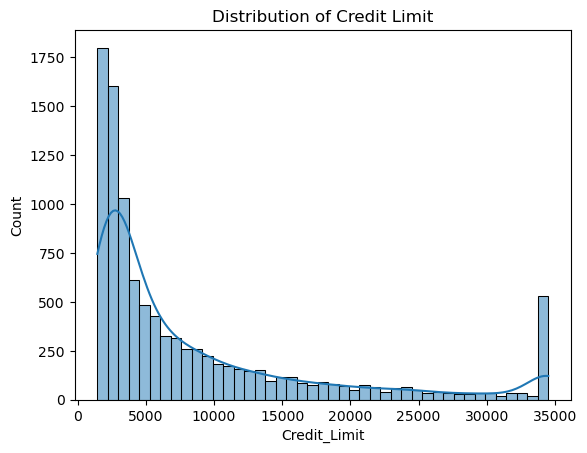

In [44]:
# Distribution of target variable
sns.histplot(y, kde=True)
plt.title("Distribution of Credit Limit")
plt.show()

<Axes: xlabel='Income_Category_encoded', ylabel='Credit_Limit'>

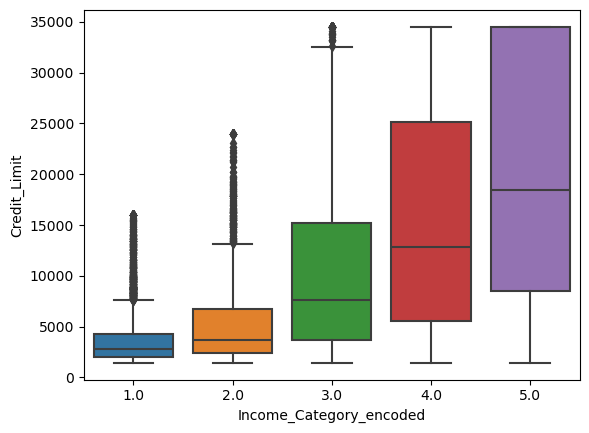

In [45]:
# Relationship between income and credit limit
sns.boxplot(x='Income_Category_encoded', y=y, data=data)

People with higher incomes have higher credit limits.

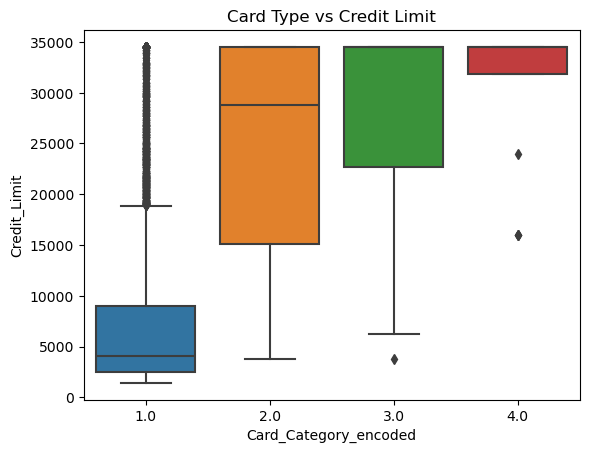

In [46]:
# Card Type and Credit Limit
sns.boxplot(x='Card_Category_encoded', y=y, data=data)
plt.title("Card Type vs Credit Limit")
plt.show()

Gold/Platinum cards have a higher limit. Blue has the lowest.

## Model comparison

---

In [47]:
models = {
  "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [48]:
results = []

In [49]:
for name, model in models.items():

    # train
    model.fit(X_train, y_train)

    # prediction
    y_pred = model.predict(X_test)

    # measuresا
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # results
    results.append({ 'Model': name,'MAE': mae,'MSE': mse,'RMSE': rmse,'R²': r2 })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by='R²', ascending=False)

print(results_df)

               Model          MAE           MSE         RMSE        R²
5  Gradient Boosting  1661.127326  1.118210e+07  3343.964770  0.868646
4      Random Forest  1319.785249  1.125251e+07  3354.475893  0.867819
3      Decision Tree  1786.737938  2.298967e+07  4794.754168  0.729944
2              Lasso  4224.249005  3.355555e+07  5792.715595  0.605829
0  Linear Regression  4224.288734  3.355580e+07  5792.736769  0.605826
1              Ridge  4224.431820  3.355675e+07  5792.819220  0.605815


Linear / Ridge / Lasso
Weaker (R² ≈ 0.60)
This means the data relationship is not linear.

<Axes: xlabel='Credit_Limit'>

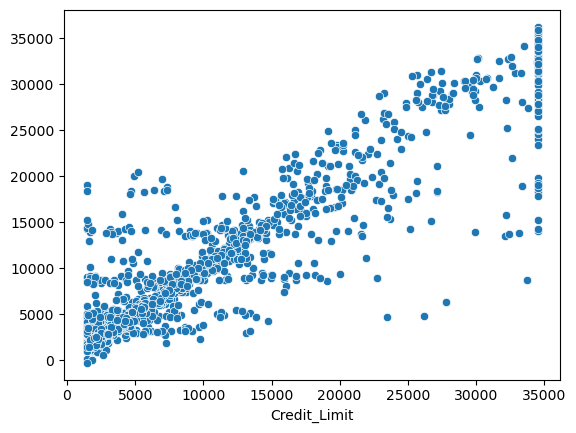

In [50]:
sns.scatterplot(x=y_test, y=y_pred)